# Multioutput Models

This section provides examples for implementing concepts related to multioutput models. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section. 

As described in the previous two sections, dimensionality reduction methods can be used to reduce the dimensionality of high-dimensional field outputs and represent them using only a few latent variables. These sections also showed how to reconstruct the high-dimensional data using the methods. However, reconstruction involved providing the methods with a high-dimensional field output. In predictive modeling, we are interested in predicting the high-dimensional outputs and we do not have access to the high-dimensional field output in reality. We want to create a multioutput model that uses a set of input variables to predict the high-dimensional field outputs. This can be done by combining the dimensionality reduction methods with interpolation and regression models, such as Gaussian process (GP) and neural network (NN) models, to create a multioutput surrogate model. 

The models described above are known as non-intrusive reduced order models (NIROMs). They are a common method for creating multioutput models to predict very high-dimensional outputs. NIROMs can be formulated mathematically as follows. 

Each dimensionality reduction method has an encoding process, $f:\mathbb{R}^n \rightarrow \mathbb{R}^k$, that projects the high-dimensional data to a low-dimensional space, and a decoding process, $g:\mathbb{R}^k \rightarrow \mathbb{R}^n$, that uses the latent variables to reconstruct the high-dimensional prediction. Consider that we have a modeling problem with an input training dataset, $\textbf{X} \in \mathbb{R}^{m \times d}$, and a corresponding output training dataset, $\textbf{Y} \in \mathbb{R}^{m \times n}$. First, we fit the dimensionality reduction method to the output training dataset, $Y$. Next, we can generate the latent variables for $Y$ using the encoding function,

$$\textbf{z} = f(\textbf{Y}),$$

where $\textbf{z} \in \mathbb{R}^{m \times k}$ are the set of latent variables obtained for $Y$. In order to predict the high-dimensional field output for a new set of inputs, $\textbf{X}^* \in \mathbb{R}^{p \times d}$, we must know the latent variables corresponding to these set of inputs. We must create a way to predict the latent variables for this new set of inputs. This is where we use interpolation or regression models to create a mapping, $h: \mathbb{R}^d \rightarrow \mathbb{R}^k$, that provides a prediction of the latent variables for a new set of inputs. 

To do this, we have to train GP or NN models with $\textbf{X}$ as the input dataset and $\textbf{z}$ as the output data set. The GP or NN model will act as the mapping $h$ between the inputs and the latent variables. Since the latent variable space is multi-dimensional, multiple independent GP models will be trained, one for each latent variable, if GP models are used. Now that we have this mapping, we can generate a prediction of the latent variables using the mapping,

$$\textbf{z}^* = h(\textbf{X}^*).$$

After the prediction of the latent variables is obtained, the high-dimensional field output prediction can be obtained using the decoding process as

$$\textbf{Y}^* = g(\textbf{z}^*).$$

This is the overall mathematical process of constructing a NIROM. In this section, we will demonstrate how to create such surrogate models using the `scimlstudio` package. The first block of code will import the relevant packages for constructing these models. To learn more about such surrogate models, you can read the publications below. 

[1] [K. Decker, H. D. Schwartz, and D. Mavris, “Dimensionality reduction techniques applied to the design of hypersonic aerial systems,” in AIAA AVIATION 2020 FORUM, Virtual Conference, Jun. 2020](https://arc.aiaa.org/doi/10.2514/6.2020-3003)

[2] [Halder, Rakesh, Krzysztof J. Fidkowski, and Kevin J. Maki. "Non‐intrusive reduced‐order modeling using convolutional autoencoders." International Journal for Numerical Methods in Engineering 123.21 (2022).](https://onlinelibrary.wiley.com/doi/full/10.1002/nme.7072)

[3] [Wang, Jing, et al. "Flow field prediction of supercritical airfoils via variational autoencoder based deep learning framework." Physics of Fluids 33.8 (2021).](https://pubs.aip.org/aip/pof/article/33/8/086108/1080382)

[4] [Yang, Muchen, and Zhixiang Xiao. "POD-based surrogate modeling of transitional flows using an adaptive sampling in Gaussian process." International Journal of Heat and Fluid Flow 84 (2020).](https://www.sciencedirect.com/science/article/pii/S0142727X1931210X)


> __*NOTE*__: You may see some warnings when running the code in this section. These can be safely ignored. 

In [1]:
import torch
from scimlstudio.models import FeedForwardAutoencoder, POD, FeedForwardNeuralNetwork
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from pyDOE3 import lhs
from scimlstudio.utils import Standardize, Normalize
from scimlstudio.utils import evaluate_vector
from gpytorch.mlls import ExactMarginalLogLikelihood
from scimlstudio.models import SingleOutputGP

# defining the device and data types
args = {"device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'), "dtype": torch.float32}

/home/abhijnan/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment Model Function

The non-intrusive reduced order modeling method will be demonstrated using the [Environment Model Function (EMF)](https://www.sfu.ca/~ssurjano/environ.html) that can be described as follows:

$$h(s,t|\textbf{x})= \frac{M}{\sqrt{4\pi Dt}}\text{exp}(\frac{-s^2}{4Dt}) + \frac{1_{t>\tau}M}{\sqrt{4\pi D(t-\tau)}}\text{exp}(\frac{-(s-L)^2}{4D(t-\tau)}).$$

This is the same function that was used in previous sections to demonstrate the [POD]((https://computationaldesignlab.github.io/surrogate-methods/pod.html)) and [autoencoder](https://computationaldesignlab.github.io/surrogate-methods/autoencoder.html) dimensionality reduction method. More details about the function and contour plots of the function can be found in these previous sections. The EMF is evaluated on a 32 x 32 grid for $(s,t)$ which means that there are a total of 1024 values to model for the EMF over this grid.

In the previous sections, it has been demonstrated how to reduce the dimensionality of the EMF and also reconstruct the function using POD and autoencoders. Here, in this section, it will be demonstrated how to predict the EMF for a given set of input values for $M, D, L$ and $\tau$. This represents a prediction problem where the entire field output of the EMF must be predicted given a set of inputs. The next block of code defines the EMF. 

In [2]:
# defining the grid for the function
s_grid = torch.linspace(0.0, 2.50, 32, **args)
t_grid = torch.linspace(15.0, 60.0, 32, **args)
Sgrid, Tgrid = torch.meshgrid(s_grid, t_grid, indexing='ij')

def env_model_function(x: torch.Tensor) -> torch.Tensor:
    """
        Parameters
        ----------
        x: torch.Tensor
            2D tensor array with the inputs to the function

        Returns
        -------
        y: torch.Tensor
            Values of the EMF evaluated for the given inputs

    """

    # extracting values of variables
    M = x[0]
    D = x[1]
    L = x[2]
    tau = x[3]

    first_term = (M/torch.sqrt(4 * torch.pi * D * Tgrid)) * torch.exp(-(Sgrid**2)/(4*D*Tgrid))
    second_term = (M/torch.sqrt(4 * torch.pi * D * (Tgrid - tau))) * torch.exp(-((Sgrid - L) ** 2)/(4*D*(Tgrid - tau)))
    second_term[torch.isnan(second_term)] = 0.0
    y = first_term + second_term

    return y

We will first generate training and testing data for the non-intrusive reduced order model. 1000 training samples and 50 testing samples will be generated. Latin hypercube sampling (LHS) is used to generate the training and testing data for the model. 

In [3]:
# defining the bounds
l_bounds = torch.tensor([7.0, 0.02, 0.01, 30.01], **args)
u_bounds = torch.tensor([13.0, 0.12, 3.0, 30.295], **args)

# training data generation
train_samples = torch.tensor(lhs(n=4, samples=200, criterion='cm', iterations=100), **args)
xtrain = l_bounds + (u_bounds - l_bounds) * train_samples
ytrain = torch.stack([env_model_function(x) for x in xtrain]) # this uses a 32x32 grid leading to a total of 1024 outputs
print(f"Shape of training data: {xtrain.shape}")

# testing data generation
test_samples = torch.tensor(lhs(n=4, samples=50, criterion='cm', iterations=100), **args)
xtest = l_bounds + (u_bounds - l_bounds) * test_samples
ytest = torch.stack([env_model_function(x) for x in xtest])
print(f"Shape of testing data: {xtest.shape}")

Shape of training data: torch.Size([200, 4])
Shape of testing data: torch.Size([50, 4])


## Proper Orthogonal Decomposition + Gaussian Process models

As described above, the NIROM surrogate modeling method uses a dimensionality reduction method along with a interpolation or regression model to predict high-dimensional outputs. One example of such a model can be constructed using POD as the dimensionality reduction method and GP models as the interpolation model for the low-dimensional latent space. One bottleneck that can occur with the use of GP models for the latent space is that the latent space is multi-dimensional. There are GP models that can predict multiple outputs, but these are out of the scope of this book. So, we will use a collection of independent GP models, one for each latent variable, to model the latent variables.

The next block of code performs POD to generate the latent space for the EMF training data and also calculates the latent variables by projecting the high-dimensional data to the low-dimensional latent space.

In [4]:
# defining the pod model and generating the latent variables for the training data
pod = POD(s_train=ytrain.flatten(1).mT, ric=0.9999, snapshot_transform=Standardize(ytrain.flatten(1)))
pod.fit()
latent_vars_pod = pod.encoding(ytrain.flatten(1).mT)

The next code block trains a collection of GP models where each GP model is trained to predict one of the latent variables obtained from POD. The trained GP models are then stored in a list which can be used later to generate the predictions of the GP models and predict the high-dimensional field output of the EMF. The training process of the GP models follows the procedure introduced in the [GP modeling section](https://computationaldesignlab.github.io/surrogate-methods/gp_models/gp_models.html).

In [5]:
gp_models_pod = []
for i in range(latent_vars_pod.shape[-1]):
    latent_train = latent_vars_pod[:,i]
    gp = SingleOutputGP(x_train=xtrain, y_train=latent_train.reshape(-1,1), output_transform=Standardize, input_transform=Normalize)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # loss function 
    optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer
    gp.fit(training_iterations=500, mll=mll, optimizer=optimizer)
    gp_models_pod.append(gp)

/home/abhijnan/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/abhijnan/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


Now, that the complete model has been trained, the next code block demonstrates how to generate predictions for the testing data using the list of GP models. The high-dimensional field output prediction is then obtained by stacking the mean predictions from the GP modeld and using the decoding function from the POD class to generate the field output prediction. Mathematically, this can be written as,

$$\textbf{Y}^* = U_k \mathbb{E}[\textbf{z}^*],$$

where $U_k$ are the POD modes and $\mathbb{E}[\textbf{z}^*]$ represents the mean prediction of the latent variables obtained from the GP models. 

Since we are using GP models to predict the latent variables, we can also obtain the variance in the prediction of the latent variables. We can then use the variance in the prediction of the latent variables to obtain the variance in the prediction of the field output by using the following expression. 

$$\mathbb{V}[\textbf{Y}^*] = U_k \mathbb{V}[\textbf{z}^*]$$

In [6]:
# generating predictions and variance from GP models
latent_predictions_pod = []
latent_var_pod = []
for gp in gp_models_pod:
    latent_pred, latent_std = gp.predict(xtest)
    latent_predictions_pod.append(latent_pred)
    latent_var_pod.append(latent_std**2)
latent_predictions = torch.stack(latent_predictions_pod, dim=1).squeeze(-1)
latent_variance = torch.stack(latent_var_pod, dim=1).squeeze(-1)

# applying the decoding function to obtain high-dimensional outputs
predictions_pod = pod.decoding(latent_predictions)
variance_pod = pod.snapshot_transform.std * torch.matmul(pod.modes, latent_variance.mT).mT 
predictions_pod_reshaped = predictions_pod.reshape([xtest.shape[0],32,32])
variance_pod_reshaped = variance_pod.reshape([xtest.shape[0],32,32])

/home/abhijnan/miniconda3/envs/surrogate_methods_sp26/lib/python3.12/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-06.
  warnings.warn(


After generating the predictions, the next block of code plots the field output predictions along with the variance in the prediction and the absolute error between the prediction and the testing data. This is similar to how the field output data contours were plotted in the previous sections. 

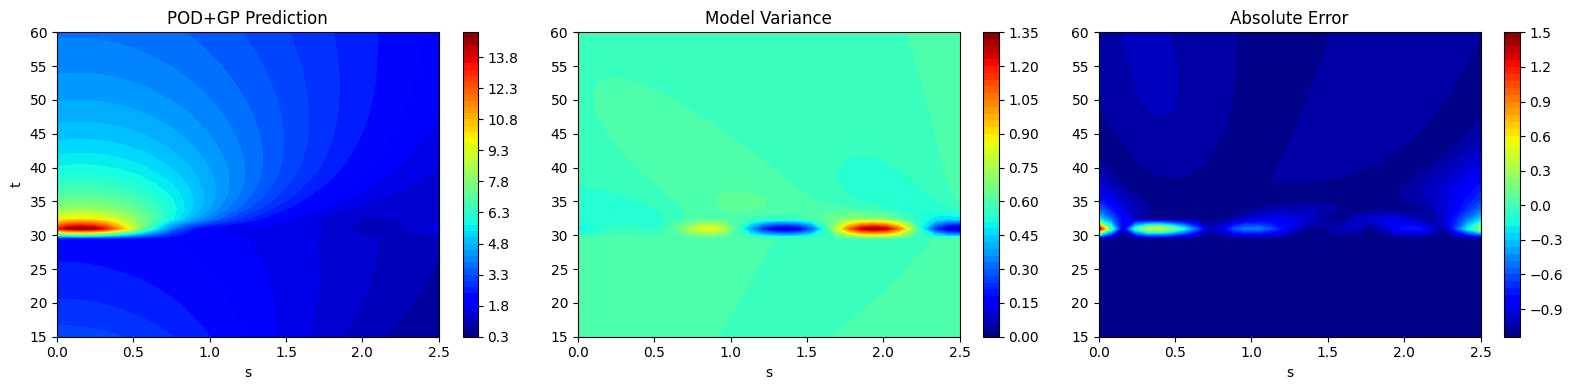

In [7]:
# plotting the reconstructions
fig, ax = plt.subplots(1,3, figsize=(16,4))

contour1 = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_pod_reshaped[15].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("POD+GP Prediction")
fig.colorbar(contour1, ax=ax[0])

contour2 = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), variance_pod_reshaped[15].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Model Variance")
fig.colorbar(contour2, ax=ax[2])

contour3 = ax[2].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(ytest[15] - predictions_pod_reshaped[15]).numpy(force=True), 
                         levels = 50, cmap='jet')
ax[2].set_xlabel("s") 
ax[2].set_title("Absolute Error")
fig.colorbar(contour3, ax=ax[1])

plt.tight_layout()

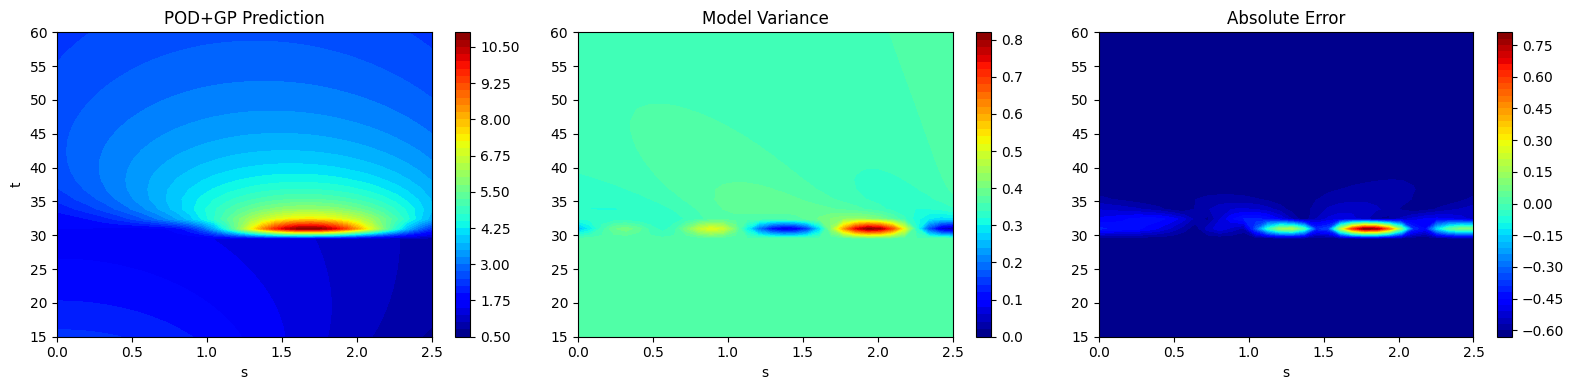

In [8]:
# plotting the reconstructions
fig, ax = plt.subplots(1,3, figsize=(16,4))

contour1 = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_pod_reshaped[20].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("POD+GP Prediction")
fig.colorbar(contour1, ax=ax[0])

contour2 = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), variance_pod_reshaped[20].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Model Variance")
fig.colorbar(contour2, ax=ax[2])

contour3 = ax[2].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(ytest[20] - predictions_pod_reshaped[20]).numpy(force=True), 
                         levels = 50, cmap='jet')
ax[2].set_xlabel("s") 
ax[2].set_title("Absolute Error")
fig.colorbar(contour3, ax=ax[1])

plt.tight_layout()

## Autoencoder + Latent Space NN Models

Another type of NIROM that can be created is a combination of an autoencoder as the dimensionality reduction method and a NN model to create the mapping between input variables and latent variables. We will construct the autoencoder model in a manner that is similar to the [autoencoder section](https://computationaldesignlab.github.io/surrogate-methods/autoencoder.html) and we will use the trained encoder network to generate the latent variables for the training data. Then, we will train a NN model using the procedure described in the [NN section](https://computationaldesignlab.github.io/surrogate-methods/nn_models.html). Since the latent variable is multi-dimensional, we will train a multi-ouput NN model by setting the dimensionality of the output layer of the NN model to be equal to the dimensionality of the latent space. 

The following block of code creates and trains the autoencoder neural network model.

In [15]:
# defining the latent space dimension
latent_space_dim = 32

# utility function from neural networks section of book for initializing the weights of the netwo
def init_weights(m):
    """
        Function for initializing the weights using glorot (or xavier) normal initialization
    """

    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_normal_(m.weight) # change this for other init methods
        m.bias.data.fill_(0.0)

# defining the encoder
encoder = torch.nn.Sequential(
    torch.nn.Linear(ytrain.flatten(1).shape[-1], 256),
    torch.nn.SiLU(),
    torch.nn.Linear(256, 64),
    torch.nn.SiLU(),
    torch.nn.Linear(64, latent_space_dim)
).to(**args)

# defining the decoder
decoder = torch.nn.Sequential(
    torch.nn.Linear(latent_space_dim, 64),
    torch.nn.SiLU(),
    torch.nn.Linear(64, 256),
    torch.nn.SiLU(),
    torch.nn.Linear(256, ytrain.flatten(1).shape[-1]),
).to(**args)

# initializing the networks
encoder.apply(init_weights)
decoder.apply(init_weights)

# defining the autoencoder
autoencoder = FeedForwardAutoencoder(x_train=ytrain.flatten(1), encoder=encoder, decoder=decoder, data_transform=Standardize(ytrain.flatten(1)))

# fitting the autoencoder model
autoencoder_optimizer = torch.optim.Adam(autoencoder.parameters, lr=1e-3)
loss_func = torch.nn.MSELoss() 

# training the autoencoder
autoencoder.fit(optimizer=autoencoder_optimizer, loss_func=loss_func, batch_size=xtrain.shape[0], epochs=5000)

The following block of code calculates the latent variables using the trained autoencoder and creates the latent space neural network model. The latent variables are generated using the training data of the model.

In [16]:
# generating latent variables
latent_vars_ae = autoencoder.encoding(ytrain.flatten(1)).detach()

# defining the network for the latent space model
network = torch.nn.Sequential(
    torch.nn.Linear(xtrain.shape[-1], 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, latent_space_dim),
).to(**args)

# initializing weights of the network
network.apply(init_weights)

# defining the feedforward neural network for learning the mapping from input space to latent space
latent_space_model = FeedForwardNeuralNetwork(xtrain, latent_vars_ae, network, input_transform=Standardize(xtrain), output_transform=Standardize(latent_vars_ae))

# training the latent space neural network model
ls_optimizer = torch.optim.Adam(latent_space_model.parameters, lr=1e-3)

latent_space_model.fit(ls_optimizer, loss_func, batch_size=xtrain.shape[0], epochs=1000)

The next block of code calculates the predictions of the high-dimensional field outputs using the predictions from the latent space NN model and the decoder network from the autoencoder. In this case, we cannot obtain the variance in the prediction as neural networks do not naturally estimate the variance in the prediction of the model.

In [17]:
# predictions of the latent space
latent_space_preds = latent_space_model.predict(xtest)

# decoding the latent space preds
predictions_ae = autoencoder.decoder(latent_space_preds)
predictions_ae_reshaped = predictions_ae.reshape([xtest.shape[0],32,32])

Now that the predictions have been calculated, we can plot the predictions of the autoencoder + latent space NN model as contour plots and also plot the absolute error between the predictions and the test data. This is done in a similar manner to previous contour plots. 

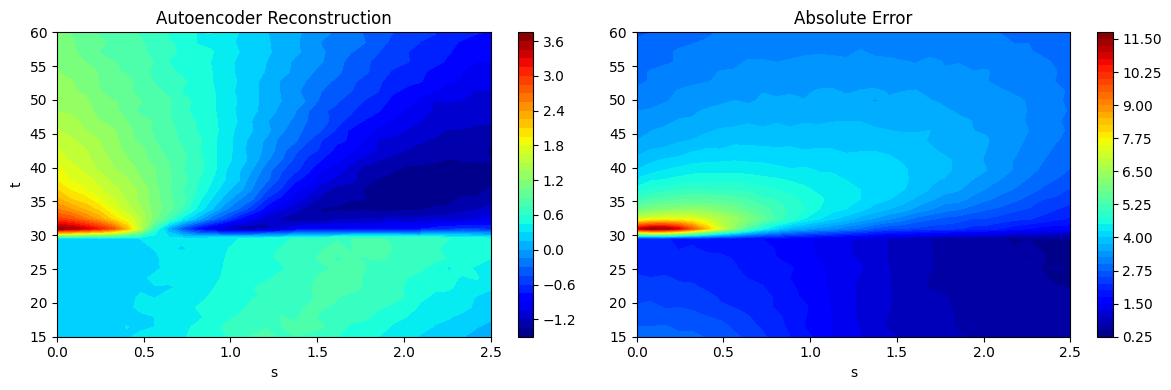

In [18]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour1 = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_ae_reshaped[15].numpy(force=True), levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder Reconstruction")
fig.colorbar(contour1, ax=ax[0])

contour2 = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(ytest[15] - predictions_ae_reshaped[15]).numpy(force=True), levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour2, ax=ax[1])

plt.tight_layout()

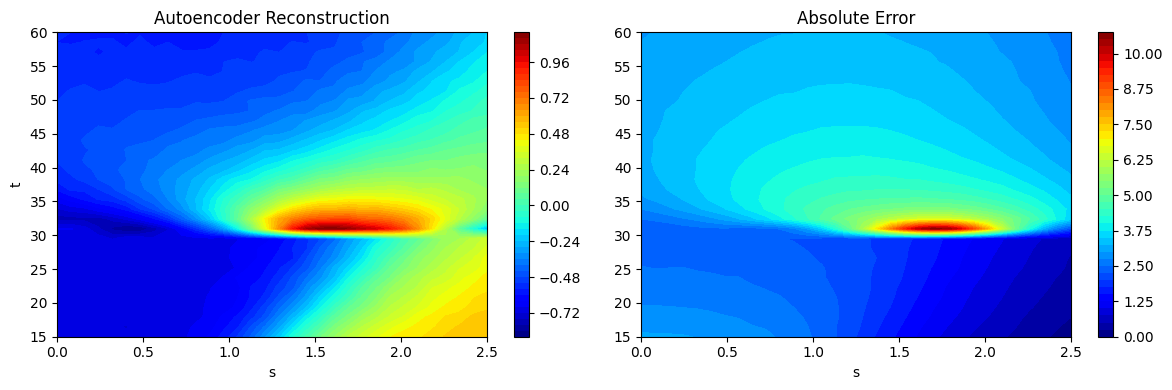

In [19]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour1 = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_ae_reshaped[20].numpy(force=True), levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder Reconstruction")
fig.colorbar(contour1, ax=ax[0])

contour2 = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(ytest[20] - predictions_ae_reshaped[20]).numpy(force=True), levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour2, ax=ax[1])

plt.tight_layout()

## NRMSE Calculation and comparison between the two models

We calculate the NRMSE for each grid point as an error metric to evaluate the overall accuracy of the two models used in this section. We plot the countours of the NRMSE for both models used here to illustrate how the error is distributed over the 2D grid of the EMF. The next block of code calculates the NRMSE for the POD and autoencoder models using the `evaluate_vector` function from `scimlstudio` and plots the NRMSE contours. 

Average value of NRMSE of autoencoder across grid: 0.061295151710510254
Average value of NRMSE of POD across grid: 0.007360708899796009


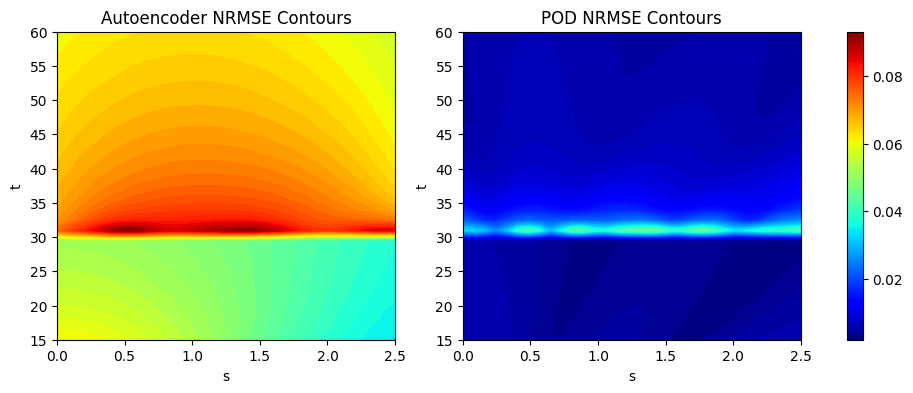

In [20]:
import numpy as np

# calculating the nrmse for each grid point
nrmse_autoencoder = evaluate_vector(true_values=ytest.flatten(1), predict_values=predictions_ae, metric="nrmse").reshape(32,32).numpy(force=True)
print(f"Average value of NRMSE of autoencoder across grid: {np.mean(nrmse_autoencoder)}")

nrmse_pod = evaluate_vector(true_values=ytest.flatten(1), predict_values=predictions_pod, metric="nrmse").reshape(32,32).numpy(force=True)
print(f"Average value of NRMSE of POD across grid: {np.mean(nrmse_pod)}")

# generating the min and max of the NRMSE contours
vmin = np.min([nrmse_autoencoder.min(), nrmse_pod.min()])
vmax = np.max([nrmse_autoencoder.max(), nrmse_pod.max()])

# plotting the nrmse contours for both models
fig, ax = plt.subplots(1,2, figsize=(12,4))
contour1 = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), nrmse_autoencoder, levels = 50, cmap='jet', vmin=vmin, vmax=vmax)
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("Autoencoder NRMSE Contours")

contour2 = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), nrmse_pod, levels = 50, cmap='jet', vmin=vmin, vmax=vmax)
ax[1].set_xlabel("s") 
ax[1].set_ylabel("t") 
ax[1].set_title("POD NRMSE Contours")

# normalzing the colorbar across both subplots
norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap='jet', norm=norm)
fig.colorbar(sm, ax=ax)